<a href="https://colab.research.google.com/github/ojaspaul123/ML-Experiments/blob/main/ML_Projects/Advertisement%20Sales%20Prediction/Ad_Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('advertising_data.csv')
df.head()

Saving advertising_data.csv to advertising_data (2).csv


,TV,Radio,Newspaper,Sales
0,23000,18500,9200,142000
1,15000,12000,6500,98000
2,31000,22000,11000,187000
3,8500,7000,3200,61000
4,27000,19500,8800,165000


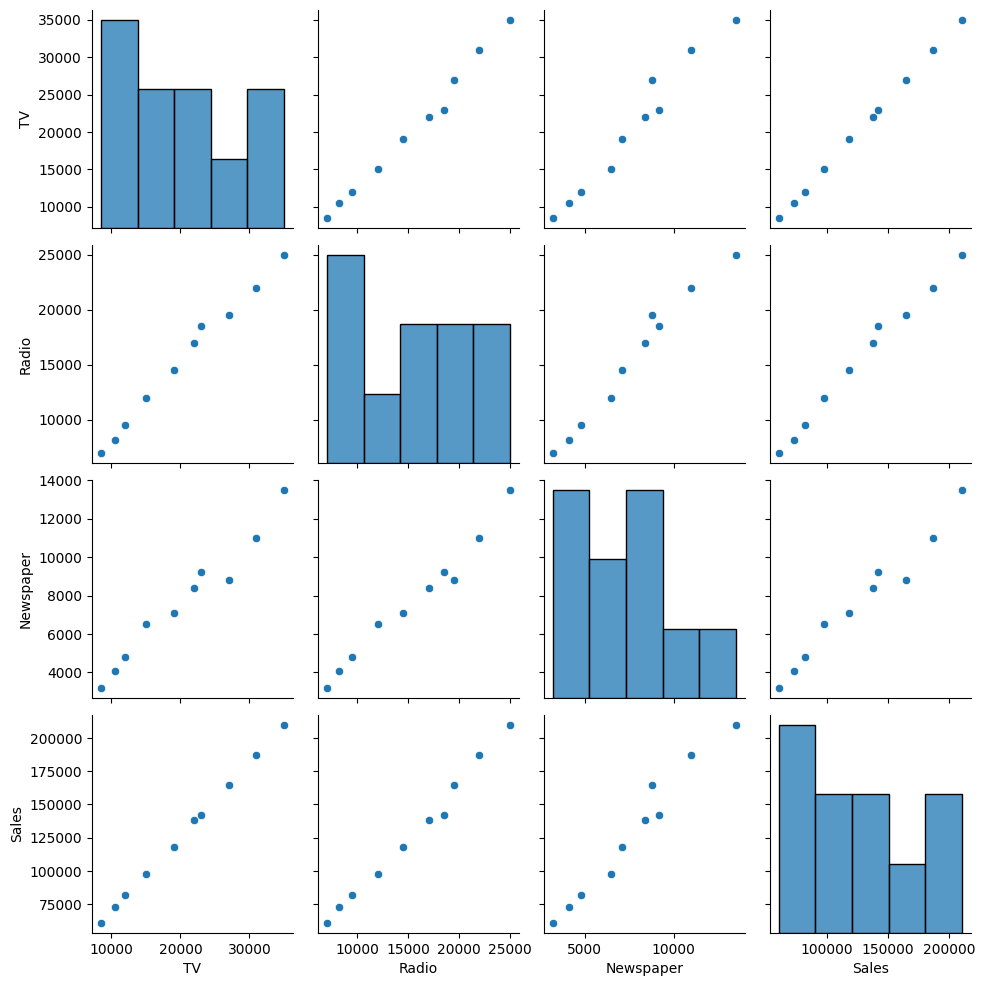

In [9]:
sns.pairplot(df)

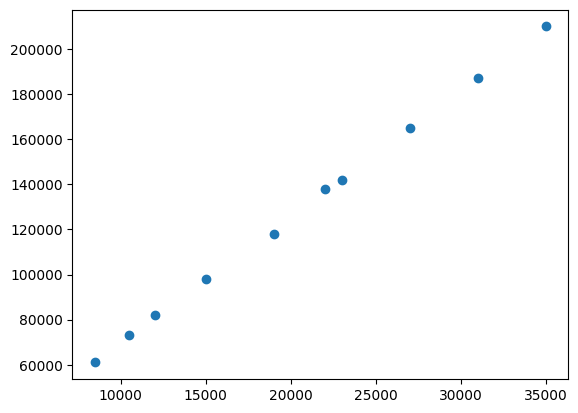

In [10]:
plt.scatter(x=df['TV'],y=df['Sales'])

In [11]:
%%markdown
---
Train Test

---
Train Test


In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,:-1],df.iloc[:,-1],test_size=0.2,random_state=42)

In [19]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((8, 3), (2, 3), (8,), (2,))

In [23]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
pred = lr.predict(X_test)


In [24]:
pred

array([136420.68054691,  97698.863099  ])

In [32]:
%%markdown
---
Metrics

---
Metrics


In [31]:
from sklearn.metrics import r2_score,mean_absolute_error
mean_absolute_error(y_test,pred)

940.2281770414265

In [30]:
r2_score(y_test,pred)


0.9967688332899529

In [34]:
def predict_sales(tv,radio,newspaper):
  features = np.array([[tv,radio,newspaper]])
  res = lr.predict(features)
  return res[0]

In [33]:
df.iloc[0]

,0
TV,23000
Radio,18500
Newspaper,9200
Sales,142000


In [35]:
tv = 23000
radio = 18500
newspaper = 9200
sales = predict_sales(tv,radio,newspaper)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [36]:
sales

np.float64(141647.4620002146)

In [37]:
import pickle
pickle.dump(lr,open('Linear_regression_model.pkl','wb'))

In [40]:
%%markdown
---
From here i can deploy the prediction code into VS-Code to web_app
---


---
From here i can deploy the prediction code into VS-Code to web_app
---
